# Quadrupole moment of higher-order topological insulators
A quadrupole insulator is a two-dimensional insulator with no polarization and no Chern number,
whose topology shows up as a zero mode at each corner of a flake, a peak in the local density of
states that STM would see at the corners and nowhere else. We will now see how to compute its
invariant, with `h.get_quadrupole_moment()`. The Wilson loop along $\vec b_1$ gives, at each
momentum $k_2$, the hybrid Wannier centers $\nu_1(k_2)$; when these Wannier bands split into a
sector with $0<\nu_1<1/2$ and one with $-1/2<\nu_1<0$, a second Wilson loop along $\vec b_2$ over
the states of one sector alone, what is called the nested Wilson loop, gives the polarization
$p_2^{\nu_1^\pm}$ of that sector along $\vec a_2$. With a mirror symmetry along each direction
every one of these polarizations is $0$ or $1/2$, and the quadrupole moment is

$$
q_{xy} = p_2^{\nu_1^-}p_1^{\nu_2^-} + p_2^{\nu_1^+}p_1^{\nu_2^+} \mod 1
$$

meaning that it is $1/2$ when the Wannier sectors are displaced by half a lattice constant along
both directions. We take the Benalcazar-Bernevig-Hughes model, a square lattice with a flux $\pi$
through each plaquette and four sites per unit cell, with a hopping $1-\delta$ inside the cell and
$1+\delta$ between cells.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import specialhamiltonian
from pyqula import topology


### The quadrupole moment across the transition
For $\delta>0$ the stronger hopping is between cells and $q_{xy}=1/2$; for $\delta<0$ it is inside
the cell and $q_{xy}=0$, the same dimerization argument as in the Su-Schrieffer-Heeger chain applied
along both directions at once. The bulk gap closes at $\delta=0$, and the Wannier gap, the distance
of the Wannier bands to $0$ and $1/2$, has to stay open for the nested Wilson loop to be defined.

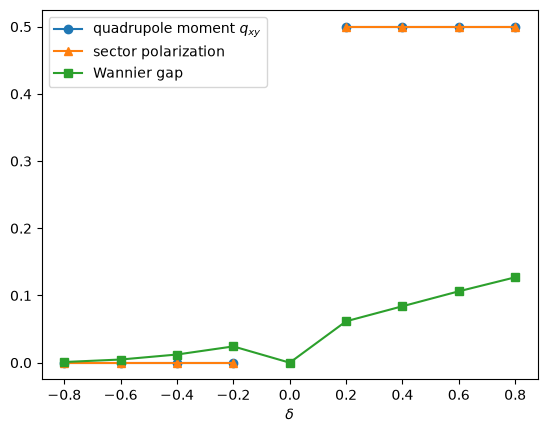

In [2]:
ds = np.linspace(-0.8,0.8,9) # hopping imbalance
qs,ps,gaps = [],[],[]
for d in ds:
    if abs(d)<1e-6: # the bulk gap closes at delta=0
        qs.append(np.nan) ; ps.append(np.nan) ; gaps.append(0.) ; continue
    h = specialhamiltonian.square_2OTI(delta=d) # Benalcazar-Bernevig-Hughes model
    qs.append(h.get_quadrupole_moment(nk=30)) # quadrupole moment
    ps.append(h.get_wannier_sector_polarization(nk=30)) # polarization of one Wannier sector
    gaps.append(topology.wannier_gap(h,nk=30)) # distance of the Wannier bands to 0 and 1/2

plt.plot(ds,qs,marker="o",label="quadrupole moment $q_{xy}$")
plt.plot(ds,ps,marker="^",label="sector polarization")
plt.plot(ds,gaps,marker="s",label="Wannier gap")
plt.xlabel("$\\delta$") ; plt.legend()
plt.show()


### Corner modes of a finite flake
The consequence of $q_{xy}=1/2$ is a zero mode at each corner of an open flake. We cut a flake of
$6\times 6$ unit cells out of the two phases and map the local density of states at zero energy:
it is concentrated at the four corners for $\delta=0.3$, and it is essentially zero everywhere for
$\delta=-0.3$, where the flake has no in-gap state at all.

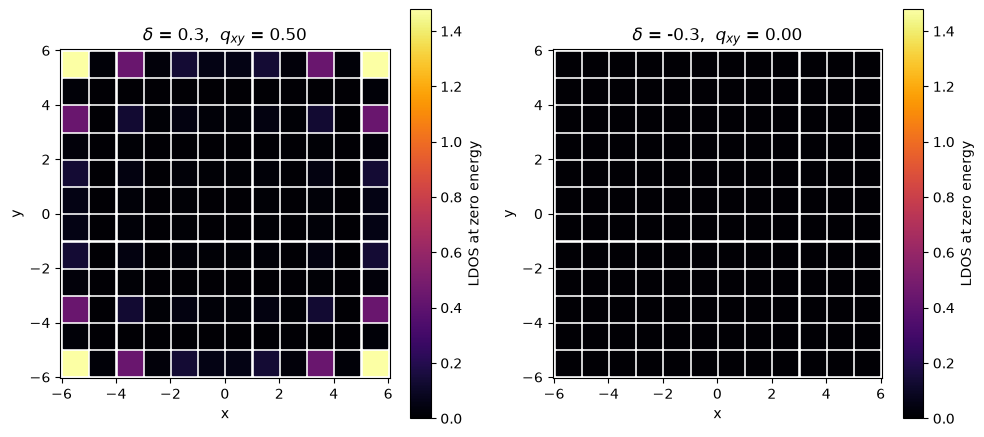

In [3]:
maps = []
for d in [0.3,-0.3]:
    h = specialhamiltonian.square_2OTI(delta=d) # Benalcazar-Bernevig-Hughes model
    q = h.get_quadrupole_moment(nk=30) # quadrupole moment
    hf = h.set_finite_system(n=6) # 6x6 flake
    (x,y,ldos) = hf.get_ldos(e=0.,delta=0.1) # local density of states at zero energy
    maps.append((d,q,x,y,ldos))

vmax = max([np.max(m[4]) for m in maps]) # same color scale for both flakes
fig,axs = plt.subplots(1,2,figsize=(10,4.5))
for (ax,(d,q,x,y,ldos)) in zip(axs,maps):
    sc = ax.scatter(x,y,c=ldos,cmap="inferno",s=300,marker="s",vmin=0.,vmax=vmax)
    fig.colorbar(sc,ax=ax,label="LDOS at zero energy")
    ax.set_title(f"$\\delta$ = {d},  $q_{{xy}}$ = {q:.2f}")
    ax.set_aspect("equal") ; ax.set_xlabel("x") ; ax.set_ylabel("y")
plt.tight_layout()
plt.show()
